[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Bluerrror/germany-hydrology/blob/main/examples/hbv_calibration.ipynb)

# 🏔️ HBV + Optuna — calibrate a rainfall–runoff model on CAMELS-DE

`germany_hydrology.hbv` is a full HBV-96 (snow, soil-moisture, two-box
response, MAXBAS routing), vectorised over parameter sets, with an
[Optuna](https://optuna.org/) TPE calibration where **you** choose the
objective (`nse` / `kge` / `log_nse` / any callable), the calibration and
validation periods, parameter bounds, and which parameters to fix.

Here we calibrate the Danube headwater gauge **DE110000 (Kirchen-Hausen)**
from CAMELS-DE and compare against the dataset's published HBV benchmark.

In [1]:
# Setup — no-op locally; on Colab installs the package + optuna
import importlib.util

if importlib.util.find_spec("germany_hydrology") is None:
    %pip install -q git+https://github.com/Bluerrror/germany-hydrology optuna

In [2]:
import earthkit.data as ekd
import matplotlib.pyplot as plt
import pandas as pd

from germany_hydrology import hbv, signatures as hs

ekd.config.set("cache-policy", "user")

GAUGE = "DE110000"
# Point at your extracted CAMELS-DE copy, or set to None to download the
# 2.2 GB archive from Zenodo (one time, cached).
CAMELS_PATH = r"D:/Agentic_AI/Packages/BVC/camels_de"

ts = ekd.from_source("camels-de", gauge=GAUGE, path=CAMELS_PATH).to_pandas()
sim_bench = ekd.from_source("camels-de", gauge=GAUGE, table="simulated",
                            path=CAMELS_PATH).to_pandas()

precip = ts["precipitation_mean"]
temp = ts["temperature_mean"]
pet = sim_bench["pet_hargreaves"].reindex(ts.index)
q_obs = ts["discharge_spec_obs"]          # mm/day — same unit HBV produces
print(f"{GAUGE}: {q_obs.notna().sum()} days of observed discharge,",
      f"{q_obs.index.min().date()} → {q_obs.index.max().date()}")

DE110000: 25075 days of observed discharge, 1951-01-01 → 2020-12-31


## Calibrate

Everything below is a user choice — try `objective="kge"` or a callable like
`lambda obs, sim: -abs(hs.pbias(obs, sim))`.

In [3]:
result = hbv.calibrate(
    precip, temp, pet, q_obs,
    objective="nse",                        # nse | kge | log_nse | callable
    calibration_period=("1971", "2000"),
    validation_period=("2001", "2020"),
    n_trials=300,
    warmup=730,                             # 2 years spin-up, excluded from scores
    fixed={"CFR": 0.05, "CWH": 0.1},        # standard practice: don't calibrate these
    seed=42,
)

print(f"calibration NSE: {result['best_score']:.3f}")
print(f"validation  NSE: {result['validation_score']:.3f}")
pd.Series(result["best_params"]).round(3)

calibration NSE: 0.854
validation  NSE: 0.801


CFR         0.050
CWH         0.100
TT         -0.365
CFMAX       1.531
SFCF        0.890
FC        256.612
LP          0.478
BETA        1.652
K0          0.750
K1          0.382
K2          0.122
UZL        20.604
PERC        4.891
MAXBAS      3.279
dtype: float64

## How does it compare to the CAMELS-DE HBV benchmark?

CAMELS-DE ships simulations from a regionally-calibrated HBV and an LSTM.
Same gauge, same validation years:

In [4]:
val = slice("2001", "2020")
sim = result["simulation"][val]
obs = q_obs[val]
bench_hbv = sim_bench["discharge_spec_sim_hbv"].reindex(obs.index)
bench_lstm = sim_bench["discharge_spec_sim_lstm"].reindex(obs.index)

rows = {}
for name, s in [("our HBV + Optuna", sim), ("CAMELS-DE HBV", bench_hbv),
                ("CAMELS-DE LSTM", bench_lstm)]:
    both = pd.concat([obs, s], axis=1).dropna()
    o, x = both.iloc[:, 0], both.iloc[:, 1]
    rows[name] = {"NSE": hs.nse(o, x), "KGE": hs.kge(o, x),
                  "PBIAS %": hs.pbias(o, x)}
pd.DataFrame(rows).T.round(3)

,NSE,KGE,PBIAS %
our HBV + Optuna,0.801,0.842,-12.079
CAMELS-DE HBV,0.819,0.900,-0.543
CAMELS-DE LSTM,0.954,0.965,-2.607


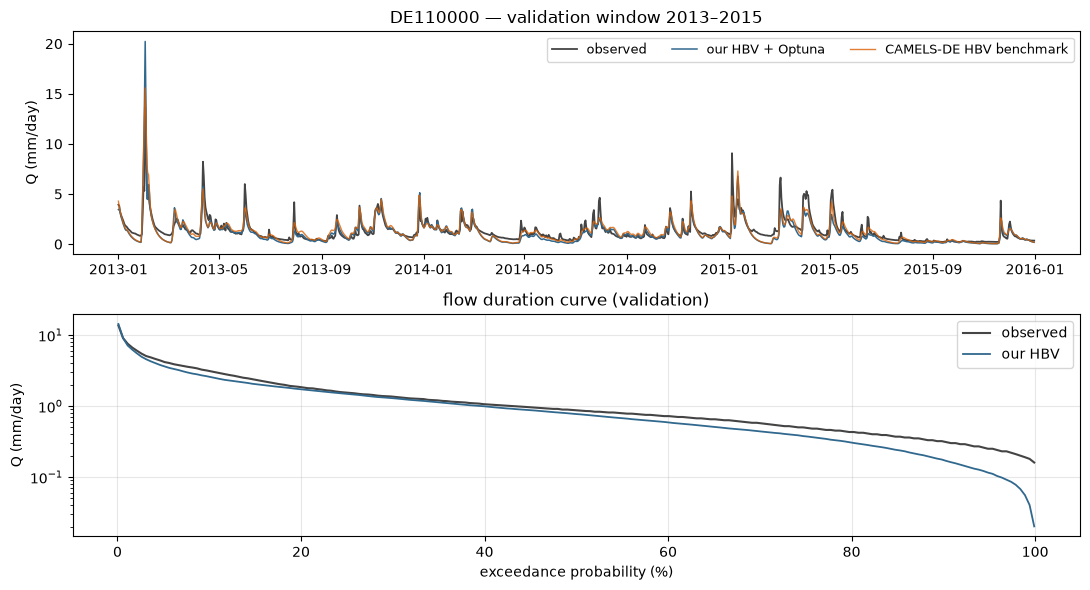

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=False)

window = slice("2013-01", "2015-12")
axes[0].plot(q_obs[window], color="#444444", lw=1.3, label="observed")
axes[0].plot(result["simulation"][window], color="#31688e", lw=1.1,
             label="our HBV + Optuna")
axes[0].plot(sim_bench["discharge_spec_sim_hbv"][window], color="#d95f02",
             lw=1.0, alpha=0.8, label="CAMELS-DE HBV benchmark")
axes[0].set_ylabel("Q (mm/day)"); axes[0].legend(ncol=3, fontsize=9)
axes[0].set_title(f"{GAUGE} — validation window 2013–2015")

fdc_obs = hs.flow_duration_curve(obs)
fdc_sim = hs.flow_duration_curve(sim.dropna())
axes[1].plot(fdc_obs.index, fdc_obs, color="#444444", lw=1.5, label="observed")
axes[1].plot(fdc_sim.index, fdc_sim, color="#31688e", lw=1.3, label="our HBV")
axes[1].set_yscale("log")
axes[1].set_xlabel("exceedance probability (%)"); axes[1].set_ylabel("Q (mm/day)")
axes[1].set_title("flow duration curve (validation)"); axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Optuna extras

The full study object is returned, so all of Optuna's tooling applies —
importance analysis tells you which parameters your objective actually
constrains (the rest are candidates for `fixed=`):

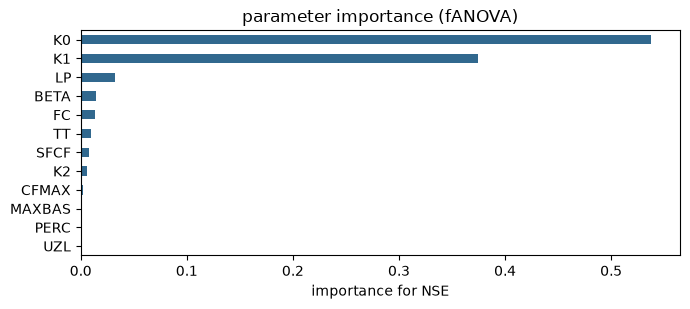

best NSE over trials: {9: 0.559, 49: 0.599, 99: 0.757, 299: 0.854}


In [6]:
import optuna

imp = pd.Series(optuna.importance.get_param_importances(result["study"]))
fig, ax = plt.subplots(figsize=(7, 3.2))
imp.sort_values().plot.barh(ax=ax, color="#31688e")
ax.set_title("parameter importance (fANOVA)")
ax.set_xlabel("importance for NSE")
plt.tight_layout(); plt.show()

trials = pd.DataFrame({"trial": range(len(result["study"].trials)),
                       "value": [t.value for t in result["study"].trials]})
print("best NSE over trials:", trials["value"].cummax().iloc[[9, 49, 99, 299]].round(3).to_dict())

Uncertainty in one extra line — because `hbv.simulate` is vectorised over
parameter sets, the top-N Optuna trials give a behavioural ensemble:

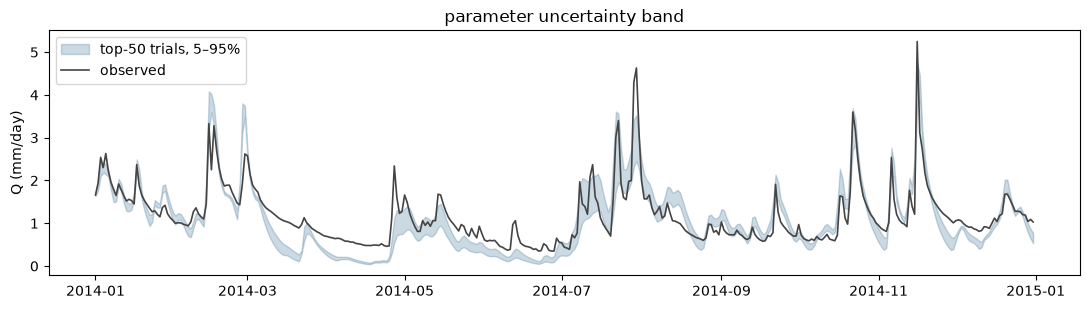

In [7]:
import numpy as np

top = sorted(result["study"].trials, key=lambda t: -(t.value or -9))[:50]
ens_params = {k: np.array([{**{"CFR": 0.05, "CWH": 0.1}, **t.params}[k] for t in top])
              for k in hbv.PARAM_BOUNDS}
ens = hbv.simulate(precip.to_numpy(), temp.to_numpy(), pet.to_numpy(), ens_params)
ens = pd.DataFrame(ens.T, index=q_obs.index)

w = slice("2014-01", "2014-12")
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.fill_between(ens[w].index, ens[w].quantile(0.05, axis=1),
                ens[w].quantile(0.95, axis=1), color="#31688e", alpha=0.25,
                label="top-50 trials, 5–95%")
ax.plot(q_obs[w], color="#444444", lw=1.2, label="observed")
ax.set_ylabel("Q (mm/day)"); ax.legend(); ax.set_title("parameter uncertainty band")
plt.tight_layout(); plt.show()

Data: CAMELS-DE (CC-BY 4.0, [Loritz et al. 2024](https://doi.org/10.5194/essd-16-5625-2024)).
Model: HBV-96 structure after Bergström & Lindström; calibration via
[Optuna](https://optuna.org/) (Akiba et al. 2019).